1. import libraries
2. delete unrelated columns
3. convert attrition to binary
4. general look

Columns: 20
Entries: 10127



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/home/efeherek/Desktop/Data_Analytics_Lab/Project/data/BankChurners.csv')


#deleting clientum id, naive bayes and avg utilization ratio columns as they are not relevant and/or raw data
df = df.iloc[:, 1:-2]

# map the target variable to binary values 
df['Attrition_Flag'] = df['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

# general look at the data
# print(df.head())
print(df.info())
sns.set_style("whitegrid")


<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  int64  
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Open_To_Buy  

Generate plots that show different correlations.

/tmp/ipykernel_15991/2005102531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition_Flag', data=df, palette='viridis')


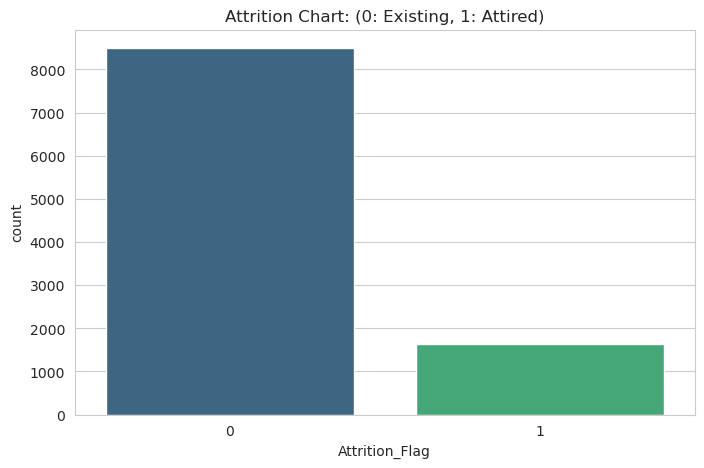

In [17]:

# How many customers are existing vs attiring?
plt.figure(figsize=(8, 5))
sns.countplot(x='Attrition_Flag', data=df, palette='viridis')
plt.title('Attrition Chart: (0: Existing, 1: Attired)')
plt.show()

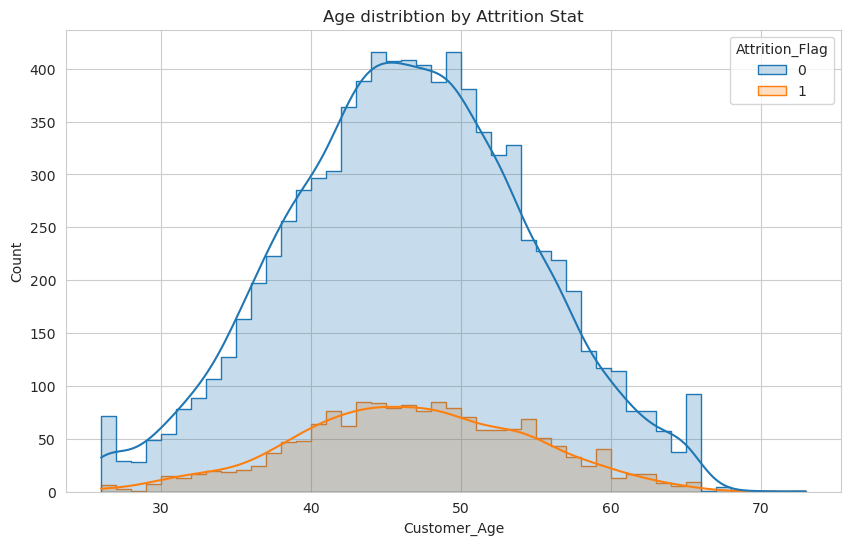

In [18]:
# Age distribution and relevance to attrition
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Customer_Age', hue='Attrition_Flag', kde=True, element="step")
plt.title('Age distribtion by Attrition Stat')
plt.show()

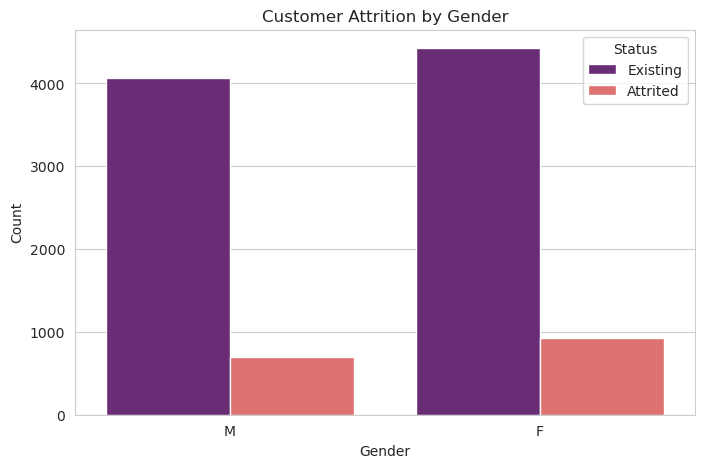

In [19]:
# Analysis of Categorical Variables (Example: Gender)
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='Attrition_Flag', data=df, palette='magma')
plt.title('Customer Attrition by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Existing', 'Attrited'])
plt.show()

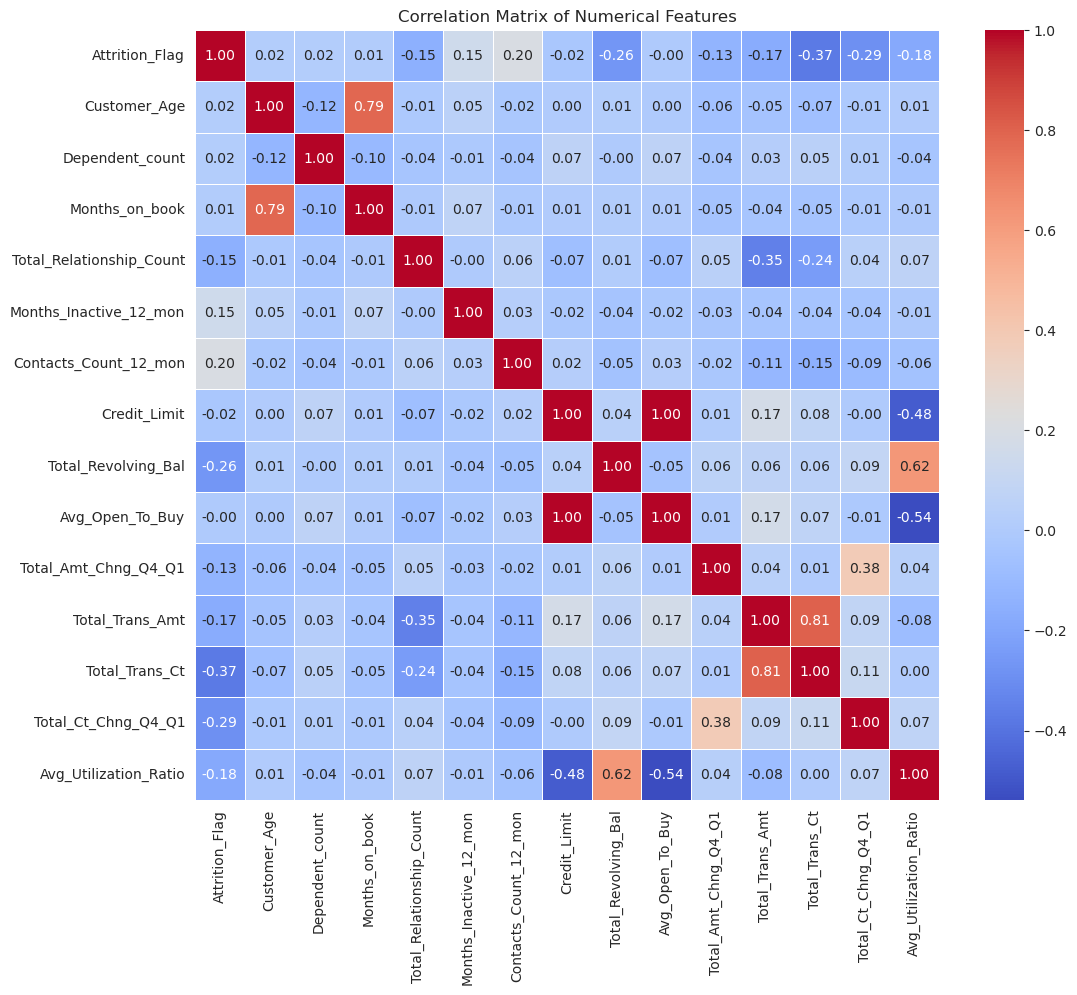

In [20]:
# Correlation Matrix (Relationship between numerical variables)
plt.figure(figsize=(12, 10))
# Selecting only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
# Calculating the correlation
corr_matrix = numeric_df.corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

1. Total_Trans_Ct (-0.37): As the number of transactions goes down, the probability of the customer leaving (Attrition) goes up. Basically, if they stop using the card, they are going to quit.  
2. Total_Ct_Chng_Q4_Q1 (-0.29): A drop in transaction count between the first and fourth quarters is a big red flag.  
3. Total_Revolving_Bal (-0.26): Customers with lower revolving balances are more likely to leave. This often suggests they aren't deeply "hooked" into the bank's credit ecosystem.  
4. Contacts_Count_12_mon (0.20): Notice this is positive. This means the more times a customer contacts the bank, the more likely they are to leave. They are probably calling to complain!

Also we see that avg_open_to but and credit_limit have a correlation of 1 this means they are basically the same so we need to remove one of them to avoid multicollinearity.because of the strong 0.79 correlation between customer age and years on book, we do the same


In [21]:
df.drop('Avg_Open_To_Buy', axis=1, inplace=True)
df.drop('Months_on_book',axis=1, inplace=True)

In [ ]:
# to check what is left in the data after drop
print(df.columns.tolist())

['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


Now that we see in the heatmap what are our biggest candidates, we add couple more visuals to see better

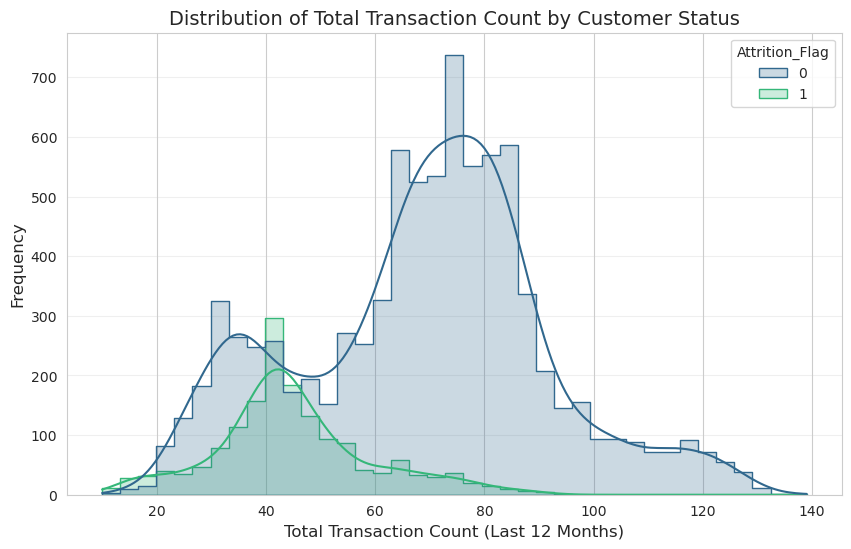

In [27]:
#total transaction count dist. and relevance to attrition because heatmap showed it has strong correlation with attrition flag
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Total_Trans_Ct', hue='Attrition_Flag', kde=True, element="step", palette='viridis')
plt.title('Distribution of Total Transaction Count by Customer Status', fontsize=14)
plt.xlabel('Total Transaction Count (Last 12 Months)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.savefig('histogram_trans_ct.png')
plt.show()

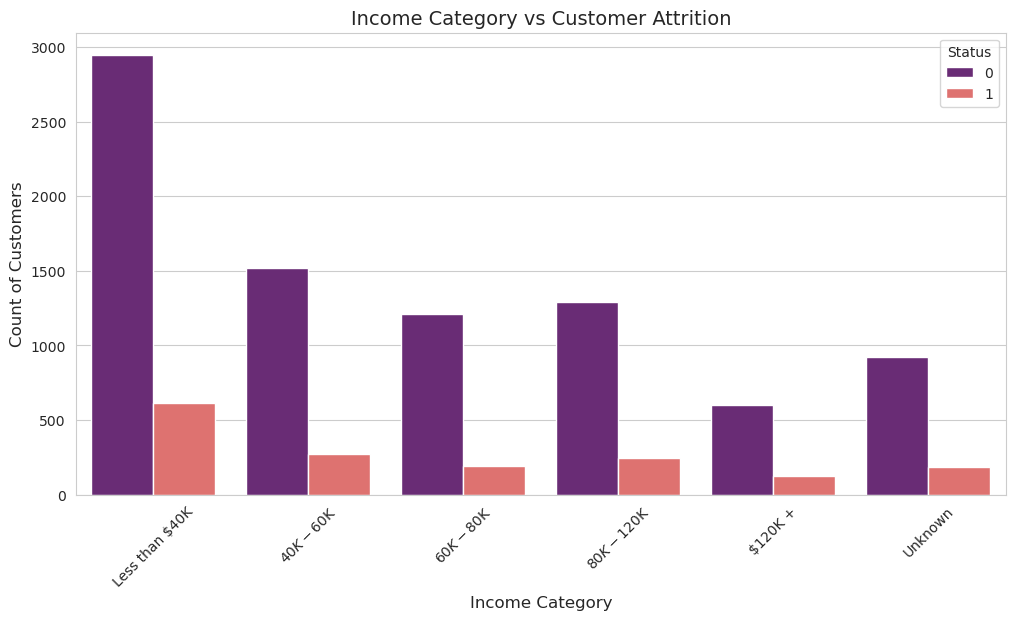

In [26]:
# Bar Chart of Income_Category
# We define a logical order for the income categories
income_order = ['Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +', 'Unknown']
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Income_Category', hue='Attrition_Flag', order=income_order, palette='magma')
plt.title('Income Category vs Customer Attrition', fontsize=14)
plt.xlabel('Income Category', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)
plt.savefig('bar_income_category.png')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.show()

/tmp/ipykernel_15991/1621766238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y='Total_Revolving_Bal', palette='coolwarm')


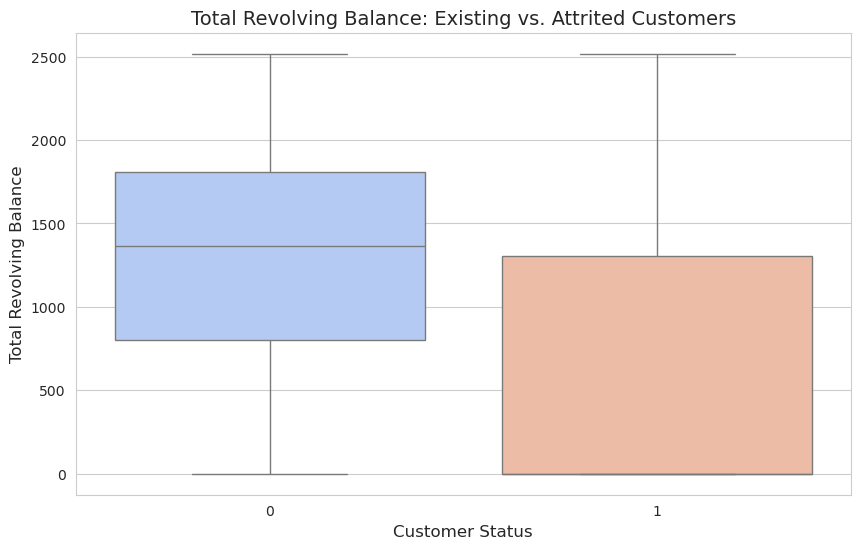

/tmp/ipykernel_15991/1621766238.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition_Flag', y='Total_Revolving_Bal', palette='coolwarm')


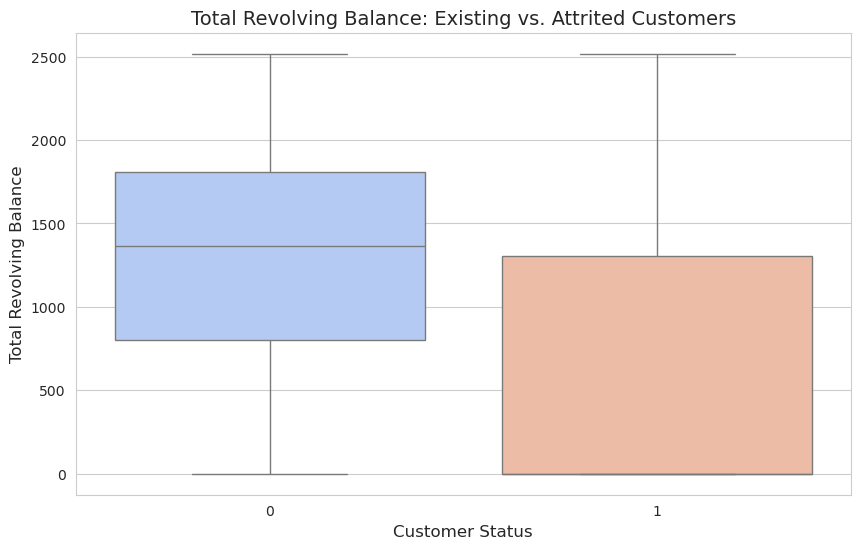

In [28]:
# Boxplot of Total_Revolving_Bal
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Revolving_Bal', palette='coolwarm')
plt.title('Total Revolving Balance: Existing vs. Attrited Customers', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Total Revolving Balance', fontsize=12)
plt.savefig('boxplot_revolving.png')
plt.show()# 4. Boxplot of Total_Revolving_Bal
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition_Flag', y='Total_Revolving_Bal', palette='coolwarm')
plt.title('Total Revolving Balance: Existing vs. Attrited Customers', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Total Revolving Balance', fontsize=12)
plt.savefig('boxplot_revolving.png')
plt.show()